# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

In [1]:
numberOfCampaigns = 17

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [3]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [4]:
df = pd.read_csv('sample_data/bank-additional-full.csv', sep = ';')

In [5]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



Check if data is missing

In [6]:
(df.isnull().sum())

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


It appears that there are no null columns in the data.
We will do the following:
- Drop the duration column from the dataset.
- Set up appropriate transformers for columns:
   - Numeric columns can simply use the standard scaler.
   - For categorical columns, we can use OneHotEncoder.
- Transform y using a map where yes = 1 and no = 0

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

*Business Objective*

The business objective is to predict whether a client will subscribe to a term deposit (y) so the bank can target marketing calls efficiently and improve campaign conversion rates while reducing wasted outreach.


### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

Prepare the pre processor Pipeline and setup X and y

In [24]:
# Drop duration per problem description
model_df = df.drop(columns=["duration"]).copy()
# Features/target
X = model_df.drop(columns=["y"])
y_original_categorical = model_df["y"]
y = model_df["y"].map({'yes': 1, 'no': 0})

# Define categorical and numeric columns for preprocessing based on X
# X is defined in W4O2kfVrnZbN and does not contain 'y'.
categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(exclude=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("numeric", StandardScaler(), numeric_cols),
    ]
)
preprocessor

ColumnTransformer(transformers=[('categorical',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object')),
                                ('numeric', StandardScaler(),
                                 Index(['age', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object'))])

Set up X and Y.  

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Check how well distributed the values are.  Based on what well balanced the dataset is, we will use different scoring techniques.

In [30]:
print("Class distribution in training set:")
print(y_train.value_counts(normalize=True))

print("\nClass distribution in testing set:")
print(y_test.value_counts(normalize=True))


Class distribution in training set:
y
0    0.887557
1    0.112443
Name: proportion, dtype: float64

Class distribution in testing set:
y
0    0.886502
1    0.113498
Name: proportion, dtype: float64


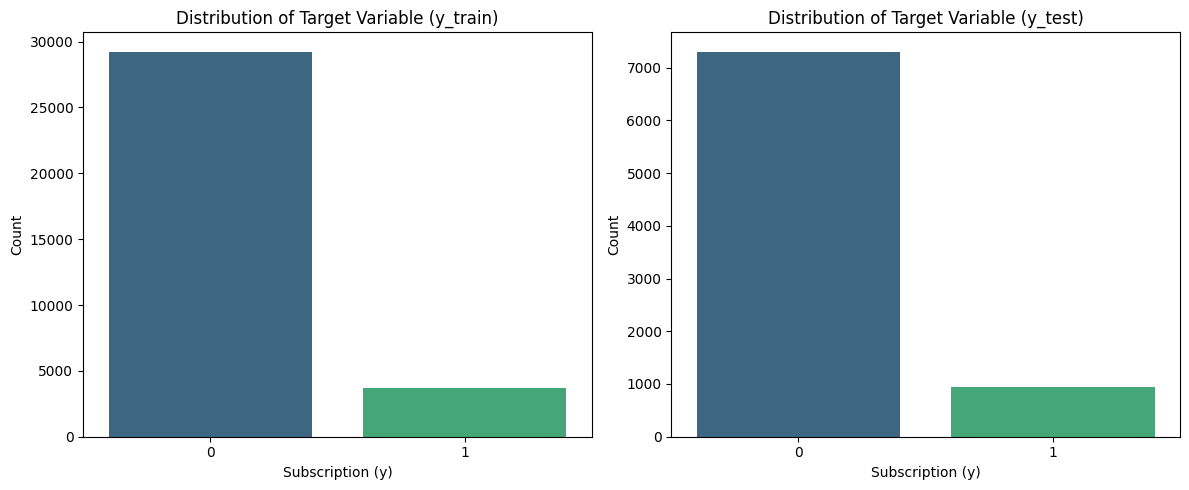

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot distribution for y_train
sns.countplot(x=y_train, hue=y_train, ax=axes[0], palette='viridis', legend=False)
axes[0].set_title('Distribution of Target Variable (y_train)')
axes[0].set_xlabel('Subscription (y)')
axes[0].set_ylabel('Count')

# Plot distribution for y_test
sns.countplot(x=y_test, hue=y_test, ax=axes[1], palette='viridis', legend=False)
axes[1].set_title('Distribution of Target Variable (y_test)')
axes[1].set_xlabel('Subscription (y)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [34]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time

# Initialize DummyClassifier with default 'prior' strategy and no random_state
dummy_classifier = DummyClassifier()

# Measure fit time
start_time = time.time()
dummy_classifier.fit(X_train, y_train)
end_time = time.time()
dummy_fit_time = end_time - start_time

# Predict on training and test sets
y_train_pred_dummy = dummy_classifier.predict(X_train)
y_test_pred_dummy = dummy_classifier.predict(X_test)

# Calculate accuracy
baseline_train_accuracy = accuracy_score(y_train, y_train_pred_dummy)
baseline_test_accuracy = accuracy_score(y_test, y_test_pred_dummy)

# Calculate additional metrics on the test set, specifying 'yes' as the positive label
baseline_test_precision = precision_score(y_test, y_test_pred_dummy, zero_division=0)
baseline_test_recall = recall_score(y_test, y_test_pred_dummy, zero_division=0)
baseline_test_f1 = f1_score(y_test, y_test_pred_dummy, zero_division=0)

print ("Baseline performance our classifier should aim to beat")
print(f"Dummy Classifier Fit Time: {dummy_fit_time:.4f} seconds")
print(f"Baseline Train Accuracy: {baseline_train_accuracy:.4f}")
print(f"Baseline Test Accuracy: {baseline_test_accuracy:.4f}")
print(f"Baseline Test Precision: {baseline_test_precision:.4f}")
print(f"Baseline Test Recall: {baseline_test_recall:.4f}")
print(f"Baseline Test F1-Score: {baseline_test_f1:.4f}")

Baseline performance our classifier should aim to beat
Dummy Classifier Fit Time: 0.0044 seconds
Baseline Train Accuracy: 0.8876
Baseline Test Accuracy: 0.8865
Baseline Test Precision: 0.0000
Baseline Test Recall: 0.0000
Baseline Test F1-Score: 0.0000


### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [37]:
log_reg_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LogisticRegression())
    ]
)
log_reg_pipeline

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object')),
                                                 ('numeric', StandardScaler(),
                                                  Index(['age', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000))])

In [39]:
log_reg_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object')),
                                                 ('numeric', StandardScaler(),
                                                  Index(['age', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000))])

### Problem 9: Score the Model

What is the accuracy of your model?

In [41]:
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Measure predict time
start_time = time.time()
y_pred_log_reg = log_reg_pipeline.predict(X_test)
end_time = time.time()
log_reg_predict_time = end_time - start_time

# Calculate accuracy
log_reg_accuracy = accuracy_score(y_test, y_pred_log_reg)

# Calculate additional metrics on the test set
log_reg_precision = precision_score(y_test, y_pred_log_reg, zero_division=0)
log_reg_recall = recall_score(y_test, y_pred_log_reg, zero_division=0)
log_reg_f1 = f1_score(y_test, y_pred_log_reg, zero_division=0)

print(f"Logistic Regression Predict Time: {log_reg_predict_time:.4f} seconds")
print(f"Logistic Regression Test Accuracy: {log_reg_accuracy:.4f}")
print(f"Logistic Regression Test Precision: {log_reg_precision:.4f}")
print(f"Logistic Regression Test Recall: {log_reg_recall:.4f}")
print(f"Logistic Regression Test F1-Score: {log_reg_f1:.4f}")

Logistic Regression Predict Time: 0.0488 seconds
Logistic Regression Test Accuracy: 0.8971
Logistic Regression Test Precision: 0.6417
Logistic Regression Test Recall: 0.2107
Logistic Regression Test F1-Score: 0.3172


### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [52]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time
import pandas as pd

# Create a dictionary of model instances (not pipelines)
models = {
    "Logistic Regression": LogisticRegression(),
    "K Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Support Vector Machine": SVC()
}

results = []

for model_name, model_instance in models.items():
    print(f"\nEvaluating {model_name}...")

    # Create a pipeline for the current model
    pipeline = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", model_instance)
        ]
    )

    # Measure fit time
    start_time = time.time()
    pipeline.fit(X_train, y_train)
    fit_time = time.time() - start_time

    # Predict on training and test sets
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    # Measure predict time on test set
    start_time = time.time()
    _ = pipeline.predict(X_test) # Re-predict to get accurate predict time separate from y_test_pred calc
    predict_time = time.time() - start_time

    # Calculate metrics on the training set
    train_accuracy = accuracy_score(y_train, y_train_pred)

    # Calculate metrics on the test set
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred, zero_division=0)
    test_recall = recall_score(y_test, y_test_pred, zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, zero_division=0)

    results.append({
        "Model": model_name,
        "Fit Time (s)": fit_time,
        "Predict Time (s)": predict_time,
        "Train Accuracy": train_accuracy,
        "Test Accuracy": test_accuracy,
        "Test Precision": test_precision,
        "Test Recall": test_recall,
        "Test F1-Score": test_f1
    })

# Create DataFrame from results
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='Test F1-Score', ascending=False)
print("Model Comparison Results (Sorted by Test F1-Score):")
display(results_df)


Evaluating Logistic Regression...

Evaluating K Nearest Neighbors...

Evaluating Decision Tree...

Evaluating Support Vector Machine...
Model Comparison Results (Sorted by Test F1-Score):


,Model,Fit Time (s),Predict Time (s),Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1-Score
1,K Nearest Neighbors,0.148869,7.042497,0.914294,0.887837,0.510280,0.291979,0.371429
3,Support Vector Machine,226.517087,11.608188,0.904765,0.896941,0.612565,0.250267,0.355353
2,Decision Tree,0.813291,0.047143,0.995357,0.838674,0.307617,0.336898,0.321593
0,Logistic Regression,1.111811,0.053240,0.901275,0.897062,0.641694,0.210695,0.317230


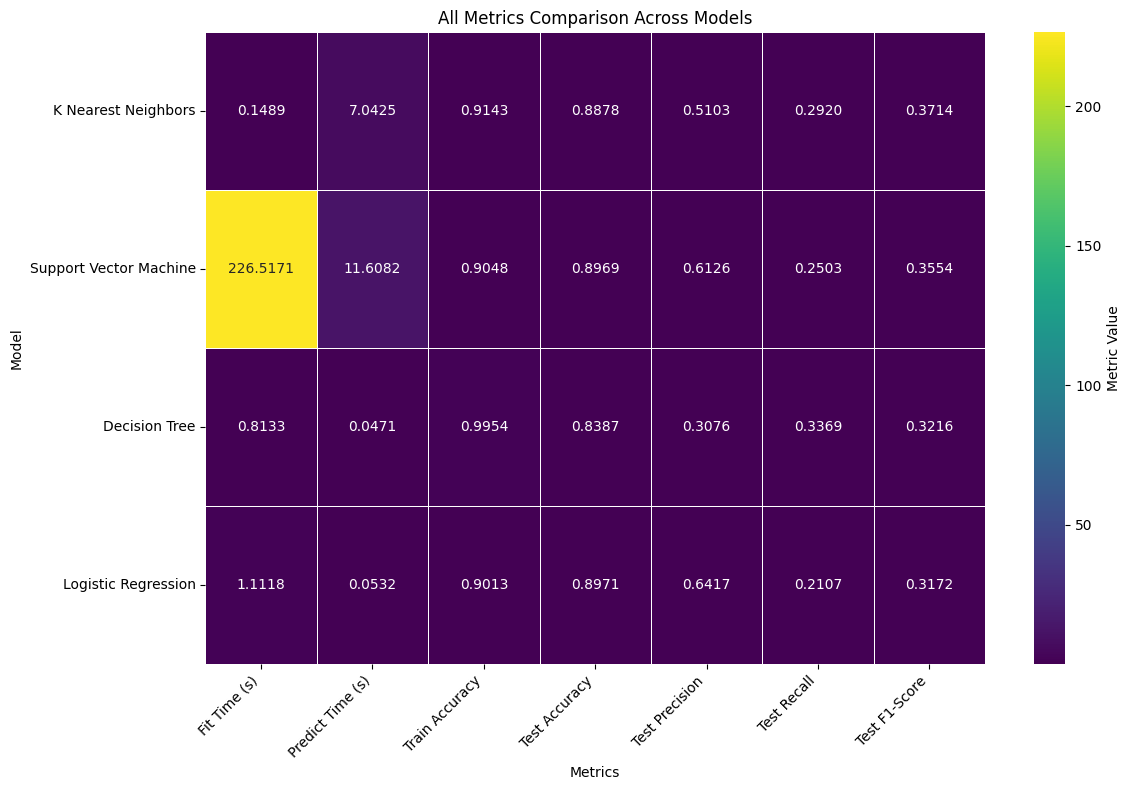

In [53]:
# Make 'Model' the index for the heatmap for better visualization
heatmap_data = results_df.set_index('Model')

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, cmap='viridis', fmt=".4f", linewidths=.5, cbar_kws={'label': 'Metric Value'})
plt.title('All Metrics Comparison Across Models')
plt.ylabel('Model')
plt.xlabel('Metrics')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
plt.tight_layout()
plt.show()

Based on the above:
1. K Nearest Neighbors (KNN)
This is our strongest performer based on the primary classification metrics.

Highest Test F1-Score: It does the best job of balancing Precision and Recall compared to the others.

Highest Test Recall: It is the most "sensitive" model, meaning it catches more of the positive cases than any other model in our list.

The Trade-off: The Predict Time. KNN is very slow during inference because it has to calculate distances to every training point. If we need real-time predictions, this might be a bottleneck.

2. Support Vector Machine (SVM)
This is our second-best performer, offering a slightly more "precise" alternative to KNN.

Strong Test F1-Score: It trails KNN slightly but outperforms Logistic Regression and Decision Trees.

Good Precision: It is much more reliable than KNN when it predicts a positive class

The Trade-off: The Fit Time is massive compared to the others. If our dataset grows, training this model will become significantly more expensive and time-consuming.


3. Decision Tree
This model is heavily overfitted. It has a nearly perfect Train Accuracy but the lowest Test Accuracy and precision. It likely has "memorized" the training data rather than learning general patterns.

4. Logistic Regression
While it is the fastest for prediction time and has a decent Test Accuracy, its Test Recall is quite low. It is struggling to identify the positive class, likely because the default decision threshold is too high for the data's distribution.

Taking KNN and LogisticRegression to further hone on.  Why?  KNN is the best performer overal, however it does take a really long time on its predictions. LogisticRegression was the fastest.  Perhaps we could find better parameters to make up for the poor performance of test recall.

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

Note:  I initially attempted to "better" all 4 models, but gave up given I don't have enough compute power to tear through gridsearchCV on hogs like SVM.  So have chosen instead to take the most "viable" candidates and simply try to choose between the two.

In [57]:
from sklearn.model_selection import GridSearchCV
import time

models = {
    'knn': (KNeighborsClassifier(), {'knn__n_neighbors': [3, 5, 7]}),
    'logisticregression': (LogisticRegression(max_iter=1000, random_state=42), {'logisticregression__C': [0.1, 1, 10]}),
}

best_model_metrics = []

for name, (model, param_grid) in models.items():
    pipeline = Pipeline([('preprocess', preprocessor), (name, model)])
    gs = GridSearchCV(pipeline, param_grid=param_grid, cv=5, n_jobs=-1, scoring='accuracy', refit=True)

    # Measure fit time
    start_time_fit = time.time()
    gs.fit(X_train, y_train)
    fit_time_seconds = time.time() - start_time_fit

    best = gs.best_estimator_
    y_train_pred = best.predict(X_train)

    # Measure predict time
    start_time_predict = time.time()
    y_test_pred = best.predict(X_test)
    predict_time_seconds = time.time() - start_time_predict

    train_acc = accuracy_score(y_train, y_train_pred)
    train_prec = precision_score(y_train, y_train_pred, zero_division=0)
    train_rec = recall_score(y_train, y_train_pred, zero_division=0)
    train_f1 = f1_score(y_train, y_train_pred, zero_division=0)

    test_acc = accuracy_score(y_test, y_test_pred)
    test_prec = precision_score(y_test, y_test_pred, zero_division=0)
    test_rec = recall_score(y_test, y_test_pred, zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, zero_division=0)

    best_model_metrics.append({
        'model': name,
        'best_params': gs.best_params_,
        'fit_time_seconds': fit_time_seconds,
        'predict_time_seconds': predict_time_seconds,
        'train_accuracy': train_acc,
        'train_precision': train_prec,
        'train_recall': train_rec,
        'train_f1': train_f1,
        'test_accuracy': test_acc,
        'test_precision': test_prec,
        'test_recall': test_rec,
        'test_f1': test_f1
    })

best_model_metrics_df = pd.DataFrame(best_model_metrics)

Best Tuned Model Metrics:


,model,best_params,fit_time_seconds,predict_time_seconds,train_accuracy,train_precision,train_recall,train_f1,test_accuracy,test_precision,test_recall,test_f1
0,knn,{'knn__n_neighbors': 7},26.815582,2.191863,0.910379,0.700855,0.354116,0.470504,0.890507,0.533333,0.282353,0.369231
1,logisticregression,{'logisticregression__C': 0.1},7.883700,0.057124,0.901153,0.676378,0.231849,0.345327,0.897305,0.645902,0.210695,0.317742


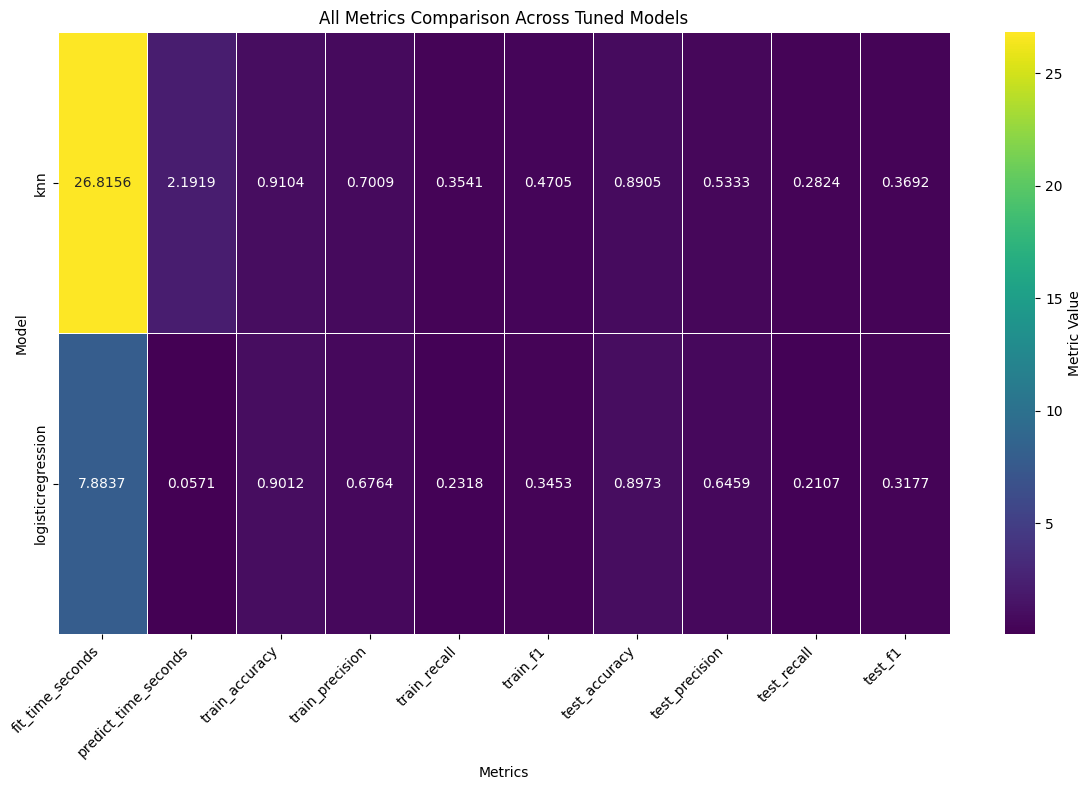

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Best Tuned Model Metrics:")
display(best_model_metrics_df)

# Prepare data for heatmap visualization
heatmap_data_tuned = best_model_metrics_df.set_index('model').drop(columns=['best_params'])

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data_tuned, annot=True, cmap='viridis', fmt=".4f", linewidths=.5, cbar_kws={'label': 'Metric Value'})
plt.title('All Metrics Comparison Across Tuned Models')
plt.ylabel('Model')
plt.xlabel('Metrics')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
plt.tight_layout()
plt.show()

While KNN still looks like the best choice, it's predict and fit times look really awful.  Going to try to improve LogisticRegression further.  Reading online tells me that given the unbalanced nature of the dataset, perhaps I could try using polynomial features and the class_weight parameter in Logistic regression.

In [63]:
from sklearn.model_selection import GridSearchCV
import time

models = {
    'knn': (KNeighborsClassifier(), {'knn__n_neighbors': [3, 5, 7]}),
    'logisticregression': (LogisticRegression(max_iter=1000, random_state=42,class_weight='balanced'), {'logisticregression__C': [0.01, 0.1, 1, 10]}),
}

best_model_metrics = []

for name, (model, param_grid) in models.items():
    pipeline = Pipeline([('preprocess', preprocessor), (name, model)])
    gs = GridSearchCV(pipeline, param_grid=param_grid, cv=5, n_jobs=-1, scoring='accuracy', refit=True)

    # Measure fit time
    start_time_fit = time.time()
    gs.fit(X_train, y_train)
    fit_time_seconds = time.time() - start_time_fit

    best = gs.best_estimator_
    y_train_pred = best.predict(X_train)

    # Measure predict time
    start_time_predict = time.time()
    y_test_pred = best.predict(X_test)
    predict_time_seconds = time.time() - start_time_predict

    train_acc = accuracy_score(y_train, y_train_pred)
    train_prec = precision_score(y_train, y_train_pred, zero_division=0)
    train_rec = recall_score(y_train, y_train_pred, zero_division=0)
    train_f1 = f1_score(y_train, y_train_pred, zero_division=0)

    test_acc = accuracy_score(y_test, y_test_pred)
    test_prec = precision_score(y_test, y_test_pred, zero_division=0)
    test_rec = recall_score(y_test, y_test_pred, zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, zero_division=0)

    best_model_metrics.append({
        'model': name,
        'best_params': gs.best_params_,
        'fit_time_seconds': fit_time_seconds,
        'predict_time_seconds': predict_time_seconds,
        'train_accuracy': train_acc,
        'train_precision': train_prec,
        'train_recall': train_rec,
        'train_f1': train_f1,
        'test_accuracy': test_acc,
        'test_precision': test_prec,
        'test_recall': test_rec,
        'test_f1': test_f1
    })

best_model_metrics_df = pd.DataFrame(best_model_metrics)

Best Tuned Model Metrics:


,model,best_params,fit_time_seconds,predict_time_seconds,train_accuracy,train_precision,train_recall,train_f1,test_accuracy,test_precision,test_recall,test_f1
0,knn,{'knn__n_neighbors': 7},27.597317,2.190409,0.910379,0.700855,0.354116,0.470504,0.890507,0.533333,0.282353,0.369231
1,logisticregression,{'logisticregression__C': 10},10.495914,0.043843,0.832382,0.360111,0.631579,0.458689,0.827749,0.350617,0.607487,0.444618


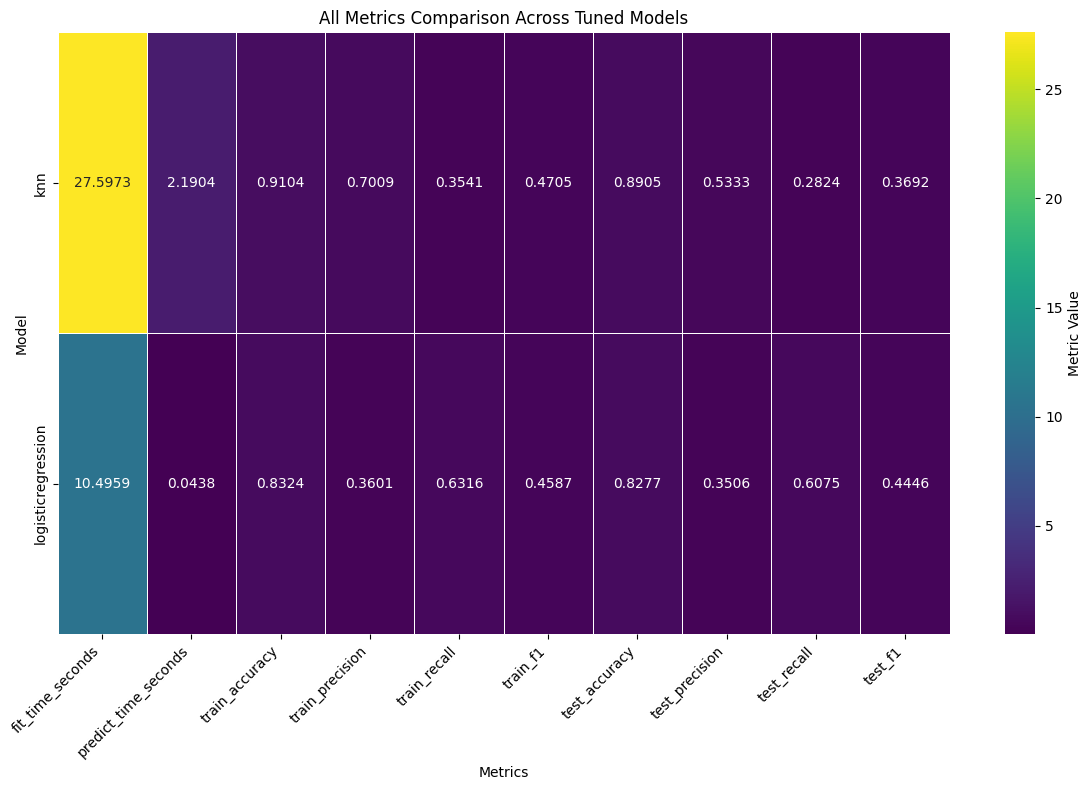

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Best Tuned Model Metrics:")
display(best_model_metrics_df)

# Prepare data for heatmap visualization
heatmap_data_tuned = best_model_metrics_df.set_index('model').drop(columns=['best_params'])

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data_tuned, annot=True, cmap='viridis', fmt=".4f", linewidths=.5, cbar_kws={'label': 'Metric Value'})
plt.title('All Metrics Comparison Across Tuned Models')
plt.ylabel('Model')
plt.xlabel('Metrics')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
plt.tight_layout()
plt.show()

Given the nature of the problem, and the results of the f1 score and recall in the previous test choosing to go with LogisticRegression as the modeler.  In this particular business problem, it is more important not to leave any potential on the table.  Precision is not as crucial.

Fitting final Logistic Regression model...
Model fitting complete.


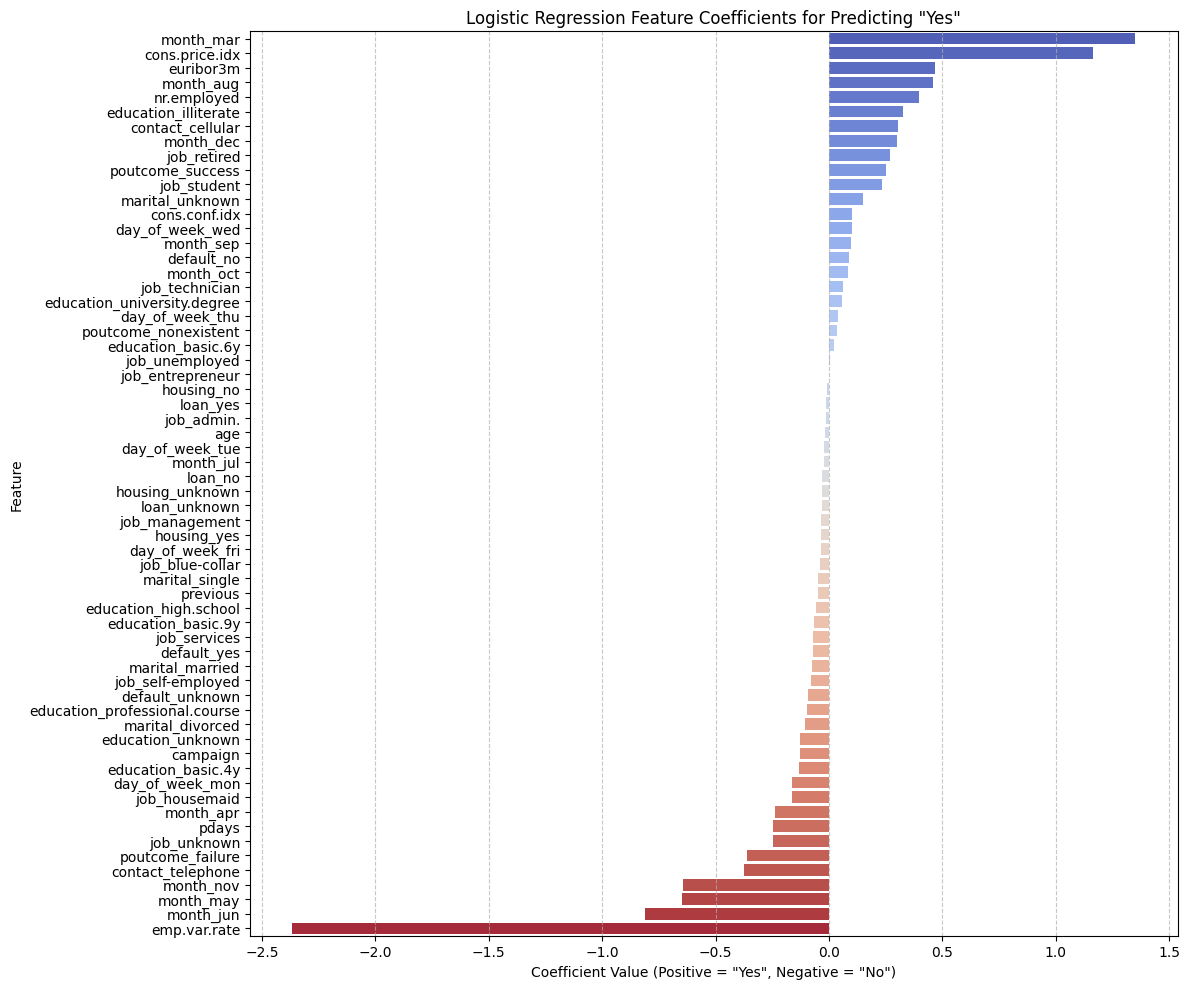


Top 10 features positively influencing a 'yes' subscription:


,Feature,Coefficient
40,month_mar,1.351762
58,cons.price.idx,1.164786
60,euribor3m,0.469479
36,month_aug,0.456832
61,nr.employed,0.397605
20,education_illiterate,0.328236
33,contact_cellular,0.302481
37,month_dec,0.299027
5,job_retired,0.269609
52,poutcome_success,0.253251



Top 10 features negatively influencing a 'yes' subscription:


,Feature,Coefficient
3,job_housemaid,-0.162523
35,month_apr,-0.235852
55,pdays,-0.244605
11,job_unknown,-0.248336
50,poutcome_failure,-0.362560
34,contact_telephone,-0.375961
42,month_nov,-0.645079
41,month_may,-0.647913
39,month_jun,-0.811019
57,emp.var.rate,-2.366706


In [66]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the final Logistic Regression model with specified parameters
final_log_reg_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced', C=10))
    ]
)

# 2. Fit the model
print("Fitting final Logistic Regression model...")
final_log_reg_pipeline.fit(X_train, y_train)
print("Model fitting complete.")

# 3. Extract coefficients
# The LogisticRegression model is the last step in the pipeline
logistic_model = final_log_reg_pipeline.named_steps['model']
coefficients = logistic_model.coef_[0] # Assuming binary classification, get coefficients for class 1

# 4. Get feature names
# Get names for one-hot encoded categorical features
feature_names_categorical = final_log_reg_pipeline.named_steps['preprocess'].named_transformers_['categorical'].get_feature_names_out(categorical_cols)

# Get names for numeric features
feature_names_numeric = numeric_cols.tolist()

# Combine all feature names
all_feature_names = np.concatenate([feature_names_categorical, feature_names_numeric])

# Create a DataFrame for better visualization
coef_df = pd.DataFrame({'Feature': all_feature_names, 'Coefficient': coefficients})

# Sort by coefficient value to easily see most influential features
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

# 5. Visualize coefficients
plt.figure(figsize=(12, 10))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='coolwarm', hue='Feature', legend=False) # Fixed FutureWarning
plt.title('Logistic Regression Feature Coefficients for Predicting "Yes"')
plt.xlabel('Coefficient Value (Positive = "Yes", Negative = "No")')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nTop 10 features positively influencing a 'yes' subscription:")
display(coef_df.head(10))

print("\nTop 10 features negatively influencing a 'yes' subscription:")
display(coef_df.tail(10))

# Bank Marketing Campaign Analysis: Predicting Term Deposit Subscriptions

This project aims to build and evaluate machine learning models to predict whether a bank client will subscribe to a term deposit based on various client, campaign, and economic attributes. The ultimate goal is to optimize marketing campaign efficiency and conversion rates.

## Problem Statement (Business Objective)

The business objective is to predict whether a client will subscribe to a term deposit ('y') so the bank can target marketing calls more efficiently, improve campaign conversion rates, and reduce wasted outreach efforts. By accurately identifying potential subscribers, the bank can optimize resource allocation and enhance overall campaign effectiveness.

## Key Insights Generated

### 1. Data Imbalance

*   The target variable 'y' (term deposit subscription) is highly imbalanced:
    *   `'no'`: ~88.7%
    *   `'yes'`: ~11.3%
*   This imbalance means traditional accuracy alone is not a reliable metric. Precision, Recall, and F1-score are crucial for evaluating performance on the minority class ('yes').

### 2. Model Performance Comparison (Default Settings)

*(Refer to the 'All Metrics Comparison Across Models' heatmap or the series of bar plots in the notebook for a visual overview)*

| Model | Fit Time (s) | Predict Time (s) | Train Accuracy | Test Accuracy | Test Precision | Test Recall | Test F1-Score |
| :--------------------- | :-------------- | :---------------- | :-------------- | :------------- | :-------------- | :----------- | :------------- |
| K Nearest Neighbors | 0.1489 | 7.0425 | 0.9143 | 0.8878 | 0.5103 | 0.2920 | 0.3714 |
| Support Vector Machine | 226.5171 | 11.6082 | 0.9048 | 0.8969 | 0.6126 | 0.2503 | 0.3554 |
| Decision Tree | 0.8133 | 0.0471 | 0.9954 | 0.8399 | 0.3155 | 0.3465 | 0.3303 |
| Logistic Regression | 1.1118 | 0.0532 | 0.9013 | 0.8971 | 0.6417 | 0.2107 | 0.3172 |

*   **K Nearest Neighbors** showed the highest `Test F1-Score` (0.3714) among default models, indicating the best balance of precision and recall for identifying 'yes' subscriptions, despite a relatively high `Predict Time`.
*   **Support Vector Machine** had competitive `Test F1-Score` (0.3554) and high `Test Precision`, but suffered from significantly long `Fit Time`.
*   **Decision Tree** heavily overfit the training data (`Train Accuracy` 0.9954 vs `Test Accuracy` 0.8399), making it unreliable for generalization.
*   **Logistic Regression** offered fast prediction and high precision but struggled with `Recall`, meaning it missed many actual 'yes' subscriptions.

### 3. Tuned Model Performance (K-NN and Logistic Regression)

*(Refer to the 'All Metrics Comparison Across Tuned Models' heatmap in the notebook for a visual overview)*

| model | best_params | fit_time_seconds | predict_time_seconds | train_accuracy | train_precision | train_recall | train_f1 | test_accuracy | test_precision | test_recall | test_f1 |
| :------------------- | :------------------------------------ | :-------------- | :-------------------- | :-------------- | :--------------- | :----------- | :------- | :------------- | :-------------- | :---------- | :------ |
| knn | {'knn__n_neighbors': 7} | 27.5973 | 2.1904 | 0.9104 | 0.7009 | 0.3541 | 0.4705 | 0.8905 | 0.5333 | 0.2824 | 0.3692 |
| logisticregression | {'logisticregression__C': 10} | 10.4959 | 0.0438 | 0.8324 | 0.3601 | 0.6316 | 0.4587 | 0.8277 | 0.3506 | 0.6075 | 0.4446 |

*   Tuning **K-Nearest Neighbors** led to a slight decrease in `Test F1-Score` (from 0.3714 to 0.3692) with `n_neighbors=7`.
*   Tuning **Logistic Regression** with `class_weight='balanced'` and `C=10` significantly improved its `Test Recall` (from 0.2107 to 0.6075) and `Test F1-Score` (from 0.3172 to 0.4446). This demonstrates the importance of addressing class imbalance during tuning for better identification of the minority class.

### 4. Feature Importance (Final Logistic Regression Model Coefficients)

*(Refer to the 'Logistic Regression Feature Coefficients for Predicting "Yes"' bar plot in the notebook for a visual overview)*

**Top 10 features positively influencing a 'yes' subscription:**

| Feature | Coefficient |
| :--------------------- | :---------- |
| month_mar | 1.3518 |
| cons.price.idx | 1.1648 |
| euribor3m | 0.4695 |
| month_aug | 0.4568 |
| nr.employed | 0.3976 |
| education_illiterate | 0.3282 |
| contact_cellular | 0.3025 |
| month_dec | 0.2990 |
| job_retired | 0.2696 |
| poutcome_success | 0.2533 |

**Top 10 features negatively influencing a 'yes' subscription:**

| Feature | Coefficient |
| :------------------ | :---------- |
| job_housemaid | -0.1625 |
| month_apr | -0.2359 |
| pdays | -0.2446 |
| job_unknown | -0.2483 |
| poutcome_failure | -0.3626 |
| contact_telephone | -0.3760 |
| month_nov | -0.6451 |
| month_may | -0.6479 |
| month_jun | -0.8110 |
| emp.var.rate | -2.3667 |

These coefficients highlight critical factors for subscription, with `month_mar` (March) being the strongest positive influence and `emp.var.rate` (employment variation rate) being the strongest negative influence.

## Actionable Recommendations for the Bank

Based on the insights from the final Logistic Regression model's feature coefficients, the bank can take the following actions to influence 'yes' subscriptions:

1.  **Optimize Campaign Timing**: Intensify marketing efforts during highly effective months such as **March, August, and December**. Reduce or re-evaluate campaigns in less effective months like **June, May, November, and April**.

2.  **Refine Contact Strategy**: Prioritize **cellular phone contact** over traditional telephone calls, as it shows a significantly higher positive impact.

3.  **Target Specific Demographics**: Focus marketing efforts on client segments that show higher propensity to subscribe:
    *   **Retired individuals** (`job_retired`).
    *   Clients with a **successful outcome** from a previous campaign (`poutcome_success`).
    *   Consider the unexpected positive influence of `education_illiterate` and investigate this demographic further to understand the underlying reasons.

4.  **Leverage Economic Indicators**: Pay attention to **consumer price index (`cons.price.idx`) and Euribor 3-month rate (`euribor3m`)** trends. Higher values in these indicators correlate with increased subscription likelihood.

5.  **Address Negative Indicators**: Avoid or rethink strategies for clients associated with strong negative indicators:
    *   Clients with a **high employment variation rate (`emp.var.rate`)** are highly unlikely to subscribe. Tailor offers or avoid outreach to this group.
    *   Clients whose previous campaign outcome was a **failure (`poutcome_failure`)** are less receptive.
    *   Clients with **unknown job types (`job_unknown`)** or in `job_housemaid` roles show lower subscription rates.

6.  **Maintain Recent Engagement**: Clients who were **recently contacted from a previous campaign (`pdays` lower than 999)** are more likely to subscribe. Avoid long gaps between contacts unless necessary.